Task I: Quantum Computing Part

In [2]:
!pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 65.4 MB/s eta 0:00:00


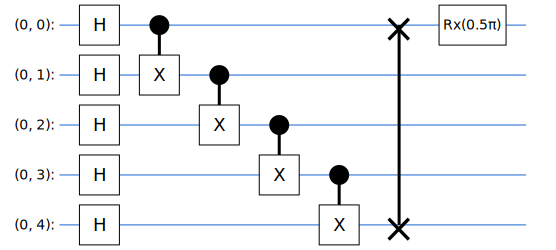

In [30]:
import cirq
from math import pi
from cirq.contrib.svg import SVGCircuit

# initialising the circuit
qubits = cirq.GridQubit.rect(1,5)
circuit = cirq.Circuit()

# applying Hadamard gates
circuit = cirq.Circuit(cirq.H(q) for q in qubits)

# applying CNOT (0, 1), (1,2), (2,3), (3,4)
circuit.append(cirq.CNOT(qubits[i], qubits[i+1]) for i in range(4))

# SWAP (0, 4)
circuit.append(cirq.SWAP(qubits[0], qubits[4]))

# X rotation pi/2 on (0,0)
circuit.append(cirq.rx(pi/2)(qubits[0]))

# plotting the circuit
SVGCircuit(circuit)

In [28]:
!python -m pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 70.5 MB/s eta 0:00:00


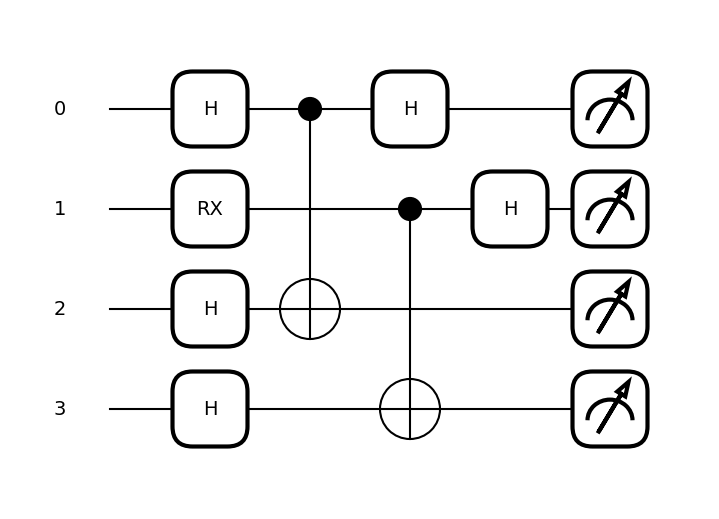

In [78]:
import pennylane as qml
import matplotlib.pyplot as plt

# defining device for initialisation
dev = qml.device('default.qubit')

# defining quantum function for initialisation
def quantum_function(x, y, z, w):
  qml.Hadamard(wires=0)
  qml.RX(pi/3, wires=1)
  qml.Hadamard(wires=2)
  qml.Hadamard(wires=3)
  # ancilla-free swap test
  qml.CNOT(wires=[0,2])
  qml.CNOT(wires=[1,3])
  qml.Hadamard(wires=0)
  qml.Hadamard(wires=1)
  return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliZ(2) @ qml.PauliZ(3))

# defining circuit for initialisation
circuit = qml.QNode(quantum_function, dev)

# drawing circuit with random parameter values
qml.drawer.use_style("black_white")
fig, ax = qml.draw_mpl(circuit)(1, 0, 1, 0)
plt.show()


Quantum machine learning is a highly important field within quantum information sciences. With the recent explosion of classical machine learning products and approaches, it is easy to overstate the impacts of frontier technologies, but simultaneously the scientific impacts cannot be understated. I think that it is easy to see that quantum computing will also have a very precise set of large impacts; especially with new quantum cryptography roadmaps/forecasting and increased interest in neutral atom quantum computing. As a result of this, I have investigate the role of quantum machine learning to speed up and efficiently process data for molecular sampling for free energy modelling. I have also used quantum neural networks with reuploading variational quantum circuits to optimise financial portfolios. I was personally impressed with the fact that my chosen circuit design was able to compress 28 data features into 14 qubits for a 7 asset portfolio, and generate a 23% return in training. I think that understanding the way information is processed in these systems is very important and so in future projects, I would like to explore this aspect. In preparation for this opportunity, independently, I would like to model a neutral atom reservoir to understand when it reaches maximal expressivity, for quantum machine learning.